This notebook performs initial snRNA-seq data processing and input generation.

## Setup

In [1]:
# Set paths
SOD1_RENV_RNA="/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-RNA/"
renv::load(SOD1_RENV_RNA)

In [2]:
# Load packages
suppressPackageStartupMessages({
  library(Seurat)
  library(SoupX)
  library(ggplot2)
  library(dplyr)
  library(BiocParallel)
  library(scDblFinder)
  library(svglite)
  library(pheatmap)
  library(matrixStats)
  library(tibble)
  library(DESeq2)
  library(VennDiagram)
  library(grid)
  library(stringr)
  library(ggrepel)
  library(ggrastr)
  library(ggpubr)
  library(forcats)
  library(ggbreak)
  library(cowplot)
  library(colorspace)
  library(broom)
  library(colorspace)
})

## Directory to save output

In [3]:
save_dir <- '/oak/stanford/groups/agitler/Shared/SOD1_Paper/RNA/'

## Create Seurat objects

In [4]:
data_dir <- '/oak/stanford/groups/agitler/Jacob/single_cell_motor_neurons/10X_analyzed/'

In [5]:
experiments <- c('SI-GA-H7', 'SI-GA-G8', '3nextseqs_11_18/3nextseq_run_10_30_midpoint_male', 
                 '3nextseqs_11_18/3nextseq_run_11_4_endpoint_male', '3nextseqs_11_18/3nextseq_run_11_8_endpoint_female',
                 '3nextseqs_11_18/3nextseq_run_11_11_endpoint_female', 'SI-GA-G7', 'SI-GA-F7', 
                 '3nextseqs_11_18/3nextseq_run_10_17_endpoint_mixed', '3nextseqs_11_18/3nextseq_run_11_1_midpoint_female_sample1',
                 '3nextseqs_11_18/3nextseq_run_11_1_midpoint_female_sample2', '3nextseqs_11_18/3nextseq_run_11_1_midpoint_female_sample3',
                 'SI-GA-H8', 'singleCellPilot/ctl_MNs_old_newREF', 'singleCell2ndExp_531/5_31_MN_sample1', 
                 'singleCell2ndExp_531/5_31_MN_sample2', 'ctl_MNs_SCRNA_6_25_all', '3nextseqs_11_18/3nextseq_run_11_5_endpoint_mixed',
                 '210727_nova_CZI/sod1_mn_nuclei_1_15', '210727_nova_CZI/sod1_mn_nuclei_1_16b', '210727_nova_CZI/sod1_mn_nuclei_2_1', 
                 '210727_nova_CZI/sod1_mn_nuclei_2_20', '210727_nova_CZI/sod1_mn_nuclei_2_9', '210727_nova_CZI/sod1_mn_nuclei_3_5')

In [6]:
create_sobj <- function(experiment_id){
    # Create Seurat object
    path <- paste0(data_dir, experiment_id, '/outs/filtered_feature_bc_matrix/')
    sobj <- Read10X(data.dir = path) %>% CreateSeuratObject()
    sobj$orig.ident <- experiment_id
    
    return(sobj)
}

In [7]:
sobj_list <- sapply(experiments, create_sobj)

## Ambient RNA removal with SoupX

In [8]:
get_soup_clusters <- function(sobj){
    sobj <- NormalizeData(sobj, verbose = FALSE)
    sobj <- FindVariableFeatures(sobj, verbose = FALSE)
    sobj <- ScaleData(sobj, verbose = FALSE)
    sobj <- RunPCA(sobj, verbose = FALSE)
    sobj <- FindNeighbors(sobj, dims = 1:20, verbose = FALSE)
    sobj <- FindClusters(sobj, resolution = 0.5, verbose = FALSE)
    
    return(sobj$seurat_clusters)
}

In [9]:
add_soup_clusters <- function(sobj){
    sobj$soup_cluster <- get_soup_clusters(sobj)
    return(sobj)
}

In [10]:
sobj_list <- sapply(sobj_list, add_soup_clusters)

In [11]:
make_soup_sobj <- function(sobj){
    experiment_id <- as.character(sobj$orig.ident[1])
    path <- data_dir <- paste0(data_dir, experiment_id, '/outs/raw_feature_bc_matrix/')
    print(path)
    raw <- Read10X(data.dir = path)
    
    sc <- SoupChannel(raw, sobj@assays$RNA@counts)
    sc <- setClusters(sc, sobj$soup_cluster)
    sc <- autoEstCont(sc, doPlot = FALSE) 
    
    adj_counts <- adjustCounts(sc, roundToInt = TRUE)
    
    # Keep original counts in original.counts assay
    sobj[["original_counts"]] <- CreateAssayObject(counts = sobj@assays$RNA@counts)
    
    # Update counts with SoupX adjusted counts
    sobj@assays$RNA@counts <- adj_counts
    
    return(sobj)
}

In [12]:
sobj_list <- sapply(sobj_list, make_soup_sobj)

[1] "/oak/stanford/groups/agitler/Jacob/single_cell_motor_neurons/10X_analyzed/SI-GA-H7/outs/raw_feature_bc_matrix/"


2823 genes passed tf-idf cut-off and 235 soup quantile filter.  Taking the top 100.

Using 1611 independent estimates of rho.

Estimated global rho of 0.01

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
"'giveCsparse' is deprecated; setting repr="T" for you"
Expanding counts from 20 clusters to 1700 cells.

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from original_counts_ to originalcounts_"


[1] "/oak/stanford/groups/agitler/Jacob/single_cell_motor_neurons/10X_analyzed/SI-GA-G8/outs/raw_feature_bc_matrix/"


2050 genes passed tf-idf cut-off and 208 soup quantile filter.  Taking the top 100.

Using 1063 independent estimates of rho.

Estimated global rho of 0.01

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
"'giveCsparse' is deprecated; setting repr="T" for you"
Expanding counts from 14 clusters to 900 cells.

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from original_counts_ to originalcounts_"


[1] "/oak/stanford/groups/agitler/Jacob/single_cell_motor_neurons/10X_analyzed/3nextseqs_11_18/3nextseq_run_10_30_midpoint_male/outs/raw_feature_bc_matrix/"


...

985 genes passed tf-idf cut-off and 53 soup quantile filter.  Taking the top 53.

Using 673 independent estimates of rho.

Estimated global rho of 0.04

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
"'giveCsparse' is deprecated; setting repr="T" for you"
Expanding counts from 25 clusters to 8497 cells.

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from original_counts_ to originalcounts_"


[1] "/oak/stanford/groups/agitler/Jacob/single_cell_motor_neurons/10X_analyzed/210727_nova_CZI/sod1_mn_nuclei_2_9/outs/raw_feature_bc_matrix/"


1007 genes passed tf-idf cut-off and 62 soup quantile filter.  Taking the top 62.

Using 544 independent estimates of rho.

Estimated global rho of 0.05

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
"'giveCsparse' is deprecated; setting repr="T" for you"
Expanding counts from 26 clusters to 9670 cells.

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from original_counts_ to originalcounts_"


[1] "/oak/stanford/groups/agitler/Jacob/single_cell_motor_neurons/10X_analyzed/210727_nova_CZI/sod1_mn_nuclei_3_5/outs/raw_feature_bc_matrix/"


954 genes passed tf-idf cut-off and 55 soup quantile filter.  Taking the top 55.

Using 370 independent estimates of rho.

Estimated global rho of 0.09

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
"'giveCsparse' is deprecated; setting repr="T" for you"
Expanding counts from 23 clusters to 10480 cells.

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from original_counts_ to originalcounts_"


## Remove mitochondrial genes

In [13]:
remove_mito <- function(sobj){
    counts <- GetAssayData(sobj, assay = "RNA")
    mito_genes <- grep( "^mt-", rownames(sobj), value = T)
    counts <- counts[-(which(rownames(counts) %in% mito_genes)),]
    sobj <- subset(sobj, features = rownames(counts))
    
    return(sobj)
}

In [14]:
sobj_list <- sapply(sobj_list, remove_mito)

## Add stage information

In [15]:
ctl.ids <- c("SI-GA-H8", "singleCellPilot/ctl_MNs_old_newREF", "singleCell2ndExp_531/5_31_MN_sample1", "singleCell2ndExp_531/5_31_MN_sample2", "ctl_MNs_SCRNA_6_25_all", "3nextseqs_11_18/3nextseq_run_11_5_endpoint_mixed")
sod.end.ids <- c("SI-GA-G7", "SI-GA-F7", "3nextseqs_11_18/3nextseq_run_10_17_endpoint_mixed", "3nextseqs_11_18/3nextseq_run_11_4_endpoint_male", "3nextseqs_11_18/3nextseq_run_11_8_endpoint_female","3nextseqs_11_18/3nextseq_run_11_11_endpoint_female")
sod.mid.ids <- c("SI-GA-H7", "SI-GA-G8", "3nextseqs_11_18/3nextseq_run_10_30_midpoint_male", "3nextseqs_11_18/3nextseq_run_11_1_midpoint_female_sample1", "3nextseqs_11_18/3nextseq_run_11_1_midpoint_female_sample2", "3nextseqs_11_18/3nextseq_run_11_1_midpoint_female_sample3")

mixed.ctl.sod.early.ids <- c("210727_nova_CZI/sod1_mn_nuclei_1_15", "210727_nova_CZI/sod1_mn_nuclei_1_16b", "210727_nova_CZI/sod1_mn_nuclei_2_1", "210727_nova_CZI/sod1_mn_nuclei_2_9")
mixed.ctl.sod.mid.ids <- c("210727_nova_CZI/sod1_mn_nuclei_2_20", "210727_nova_CZI/sod1_mn_nuclei_3_5")

In [16]:
add_stage <- function(sobj){
    if (sobj$orig.ident[1] %in% ctl.ids) {
      sobj$stage <- "ctl"
    } else if (sobj$orig.ident[1] %in% sod.end.ids) {
      sobj$stage <- "sod.end"
    } else if (sobj$orig.ident[1] %in% sod.mid.ids) {
      sobj$stage <- "sod.mid"
        
    } else if (sobj$orig.ident[1] %in% mixed.ctl.sod.early.ids) {
      sobj$stage <- ifelse(sobj$RNA["hSOD1", ] > 0, "sod.early", "ctl")
    } else if (sobj$orig.ident[1] %in% mixed.ctl.sod.mid.ids) {
      sobj$stage <- ifelse(sobj$RNA["hSOD1", ] > 0, "sod.mid", "ctl")
    }
    
    return(sobj)
}

In [17]:
sobj_list <- sapply(sobj_list, add_stage)

## Perform reference-based integration

In [18]:
# Normalize and identify variable features for each dataset independently
sobj_list <- lapply(X = sobj_list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = 2000)
})

In [19]:
saveRDS(sobj_list, file = paste0(save_dir, 'rds_files/sobj_list.rds'))

In [4]:
sobj_list <- readRDS(file = paste0(save_dir, 'rds_files/sobj_list.rds'))

In [5]:
# Select features that are repeatedly variable across datasets for integration
features <- SelectIntegrationFeatures(object.list = sobj_list)

## Use '210727_nova_CZI/sod1_mn_nuclei_2_9' as reference

In [6]:
# Choose a reference experiment
reference_exp <- c('210727_nova_CZI/sod1_mn_nuclei_2_9')
index <- match(reference_exp, names(sobj_list))

In [7]:
# Find integration anchors
all_anchors_2_9 <- FindIntegrationAnchors(object.list = sobj_list, anchor.features = features, reference = index)

Warning message in CheckDuplicateCellNames(object.list = object.list):
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Scaling features for provided objects

Finding anchors between all query and reference datasets

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 4782 anchors

Filtering anchors

	Retained 3965 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 3018 anchors

Filtering anchors

	Retained 2238 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 9650 anchors

Filtering anchors

	Retained 8112 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 8065 anchors

Filtering anchors

	Retained 6154 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 13261 anchors

Filtering anchors

	Retained 10638 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding an

In [8]:
saveRDS(all_anchors_2_9, file = paste0(save_dir, 'rds_files/all_anchors_2_9.rds'))

In [9]:
# Create an 'integrated' data assay
all_integrated_2_9 <- IntegrateData(anchorset = all_anchors_2_9)


Integrating dataset 1 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data


Integrating dataset 2 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data


Integrating dataset 3 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data


Integrating dataset 4 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data


Integrating dataset 5 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data


Integrating dataset 6 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data


Integrating dataset 7 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data


Integrating dataset 8 with reference dataset

Finding integration vectors

Finding integr

In [10]:
saveRDS(all_integrated_2_9, file = paste0(save_dir, 'rds_files/all_integrated_2_9.rds'))

In [11]:
DefaultAssay(all_integrated_2_9) <- "integrated"

# Run the standard workflow for visualization and clustering
all_integrated_2_9 <- ScaleData(all_integrated_2_9, verbose = FALSE)
all_integrated_2_9 <- RunPCA(all_integrated_2_9, verbose = FALSE)
all_integrated_2_9 <- RunUMAP(all_integrated_2_9, reduction = "pca", dims = 1:20, verbose = FALSE)
all_integrated_2_9 <- FindNeighbors(all_integrated_2_9, reduction = "pca", dims = 1:20, verbose = FALSE)
all_integrated_2_9 <- FindClusters(all_integrated_2_9, resolution = 2, verbose = FALSE)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



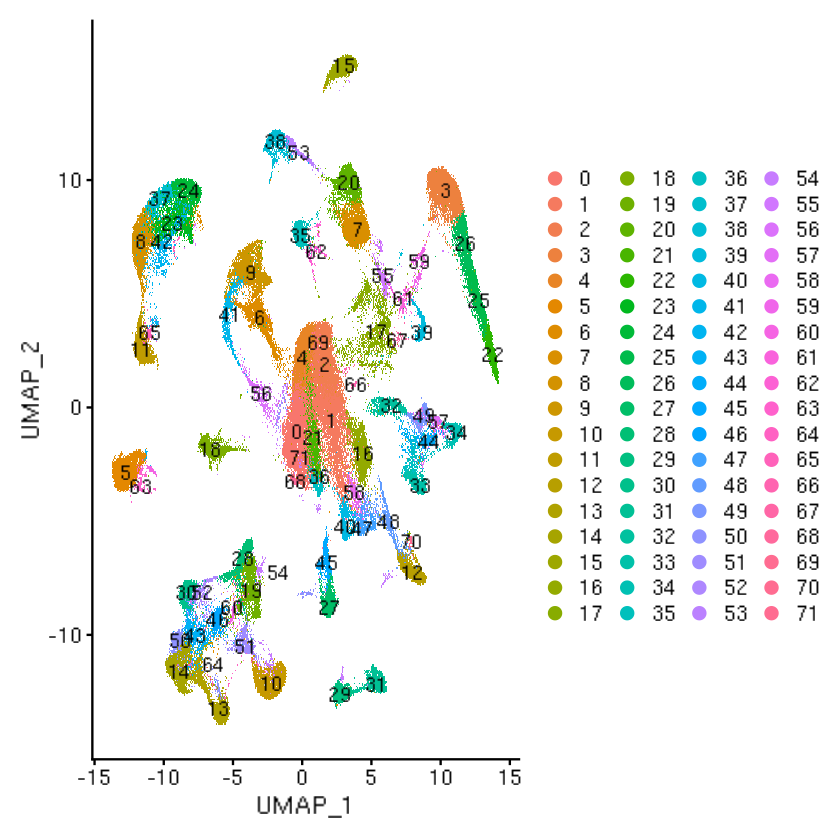

In [12]:
# Visualization
DimPlot(all_integrated_2_9, reduction = "umap", label = TRUE)

## Remove doublets/low-quality nuclei

In [14]:
all_integrated_2_9_scDblFinder <- all_integrated_2_9

In [15]:
sce <- scDblFinder(all_integrated_2_9_scDblFinder@assays$RNA@counts, samples = all_integrated_2_9_scDblFinder$orig.ident, BPPARAM=MulticoreParam(3))

Assuming the input to be a matrix of counts or expected counts.

Warning message in .checkSCE(sce):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call




In [16]:
table(sce$scDblFinder.class)


singlet doublet 
 130397   13389 

In [17]:
all_integrated_2_9_scDblFinder$scDblFinder.class <- sce$scDblFinder.class

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



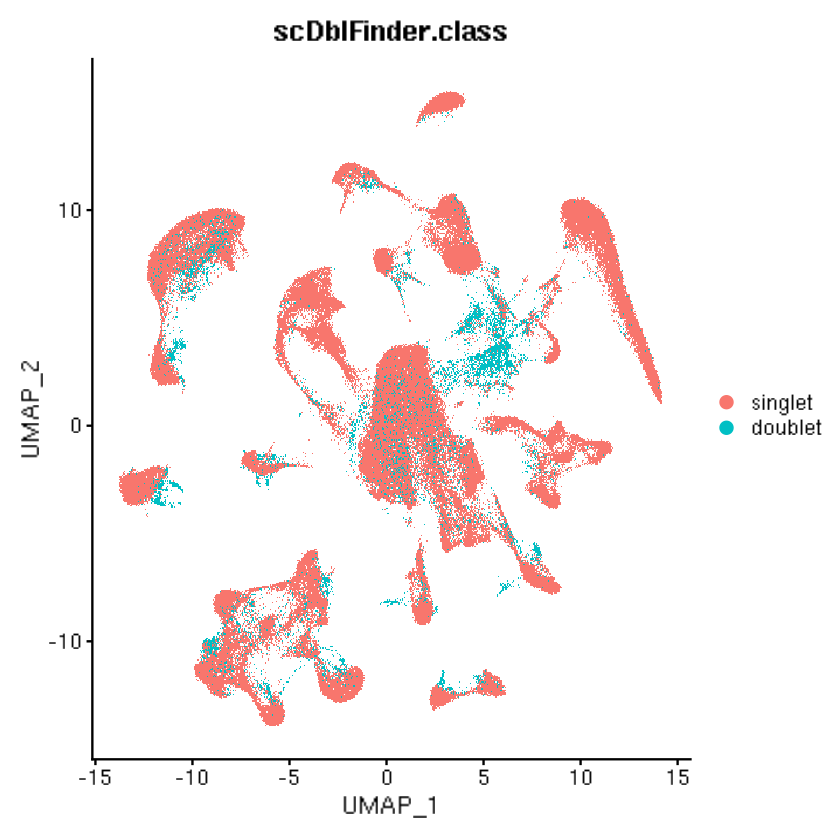

In [18]:
scDblFinder_dimplot <- DimPlot(all_integrated_2_9_scDblFinder, reduction = "umap", group.by = "scDblFinder.class")
scDblFinder_dimplot

In [17]:
ggsave(scDblFinder_dimplot, filename = paste0(save_dir, "Figures/scDblFinder_dimplot.svg"), device='svg')

Saving 6.67 x 6.67 in image



### Remove clusters with > 40% of droplets labeled as "doublet" by scDblFinder

In [19]:
all_integrated_nodub <- all_integrated_2_9_scDblFinder

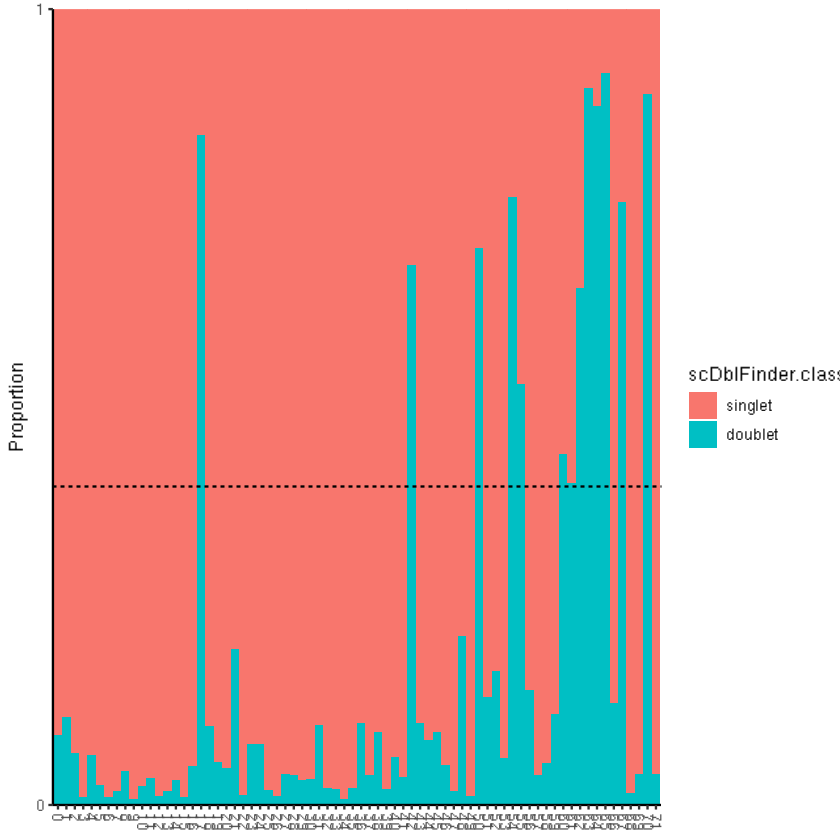

In [20]:
doublet_proportion <- ggplot(all_integrated_nodub@meta.data, aes(x=seurat_clusters, fill=scDblFinder.class)) + geom_bar(position = "fill") + scale_y_continuous(breaks=seq(0,1,by=1), expand = c(0, 0)) +
        scale_x_discrete(guide = guide_axis(angle = -90)) + ylab(expression("Proportion")) + theme_classic() + theme(axis.title.x=element_blank()) & geom_hline(linetype = "dashed", yintercept = 0.4)
doublet_proportion

In [21]:
ggsave(doublet_proportion, filename = paste0(save_dir, "Figures/doublet_proportion_new.svg"), device='svg', width = 12, height = 6, units = "in")

In [22]:
cluster_counts <- table(all_integrated_nodub@meta.data$seurat_clusters, all_integrated_nodub@meta.data[["scDblFinder.class"]])
cluster_counts_df <- as.data.frame.matrix(cluster_counts)

doublet_proportion_df <- cluster_counts_df %>%
  mutate(Cluster = rownames(cluster_counts_df),
         Proportion = doublet / (singlet + doublet)) %>%
  dplyr::select(Cluster, Proportion)

clusters_above_threshold <- doublet_proportion_df %>% filter(Proportion > 0.4) %>% pull(Cluster)
clusters_above_threshold

[1] "17" "42" "50" "54" "55" "60" "61" "62" "63" "64" "65" "67" "70"

In [23]:
# Remove clusters 
all_integrated_nodub <- subset(all_integrated_nodub, idents = clusters_above_threshold, invert = TRUE)

### Remove remaining droplets labeled as "doublet"

In [24]:
all_integrated_nodub <- subset(all_integrated_nodub, subset = scDblFinder.class == "singlet")

### Remove clusters with expression of mutually exclusive marker genes 

In [25]:
excitatory_markers <- c('Slc17a6')
inhibitory_markers <- c('Slc32a1')
astro_markers <- c('Aqp4', 'Slc1a2')
microglia_markers <- c('Csf1r')
endo_fibro_markers <- c('Cldn5', 'Dcn', 'Pdgfrb')
oligo_markers <- c('Mog', 'Sox10')
cholin_markers <- c('Slc5a7')
ependymal_markers <- c('Cfap43')
opc_markers <- c('Pdgfra')
disease_markers <- c('Atf3')
other_markers <- c('Heph', 'Mt3', 'Srxn1', 'Cox7a2', 'Atp6v1f')

all.markers <- c(excitatory_markers, inhibitory_markers, cholin_markers, oligo_markers, 
                 astro_markers, microglia_markers, endo_fibro_markers, ependymal_markers, opc_markers, 
                 disease_markers, other_markers)

Warning message:
“The following 2 features were not found in the integrated assay: Slc32a1, Cox7a2”


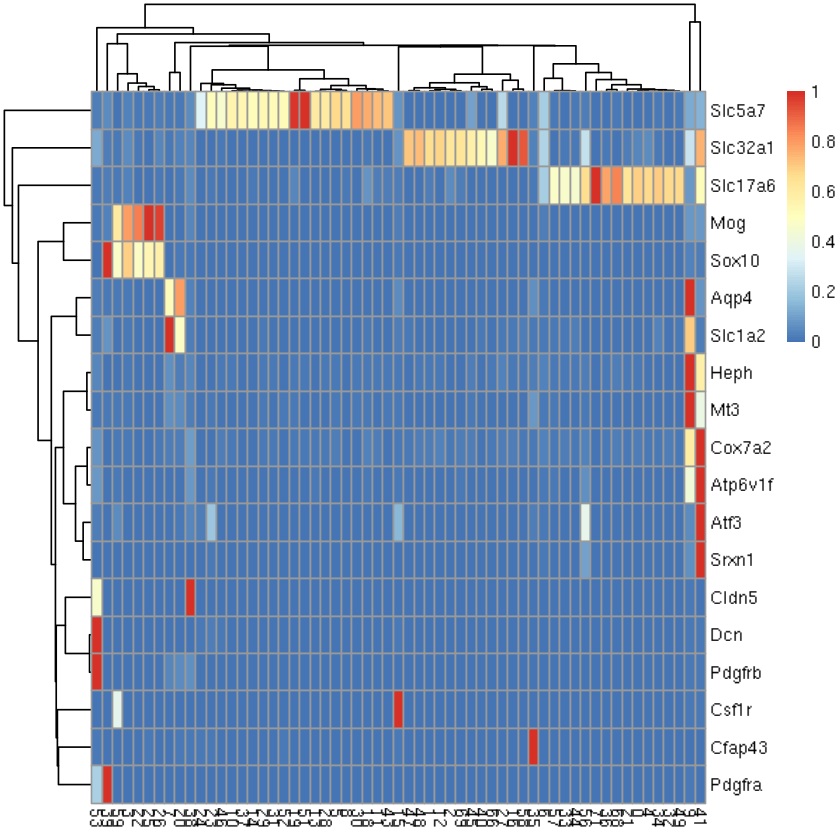

In [26]:
DefaultAssay(all_integrated_nodub) <- "RNA"

Idents(all_integrated_nodub) <- all_integrated_nodub$seurat_clusters
heatmap.avgexp <- AverageExpression(all_integrated_nodub, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))
pheatmap(heatmap.avgexp)

In [13]:
pheatmap(heatmap.avgexp, filename = paste0(save_dir, 'Figures/all_integrated_heatmap.pdf'), width = 12, height = 6)

In [27]:
# Remove clusters 
# Cluster 6: glutamatergic, GABA/glycinergic, and cholinergic neuron marker gene expression
# Cluster 59: oligodendrocyte and microglia marker gene expression
all_integrated_nodub <- subset(all_integrated_nodub, idents = c("6", "59"), invert = TRUE)

### Recluster

In [28]:
DefaultAssay(all_integrated_nodub) <- "integrated"
all_integrated_nodub <- FindNeighbors(all_integrated_nodub, reduction = "pca", dims = 1:20, verbose = FALSE)
all_integrated_nodub <- FindClusters(all_integrated_nodub, resolution = 0.8, verbose = FALSE)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



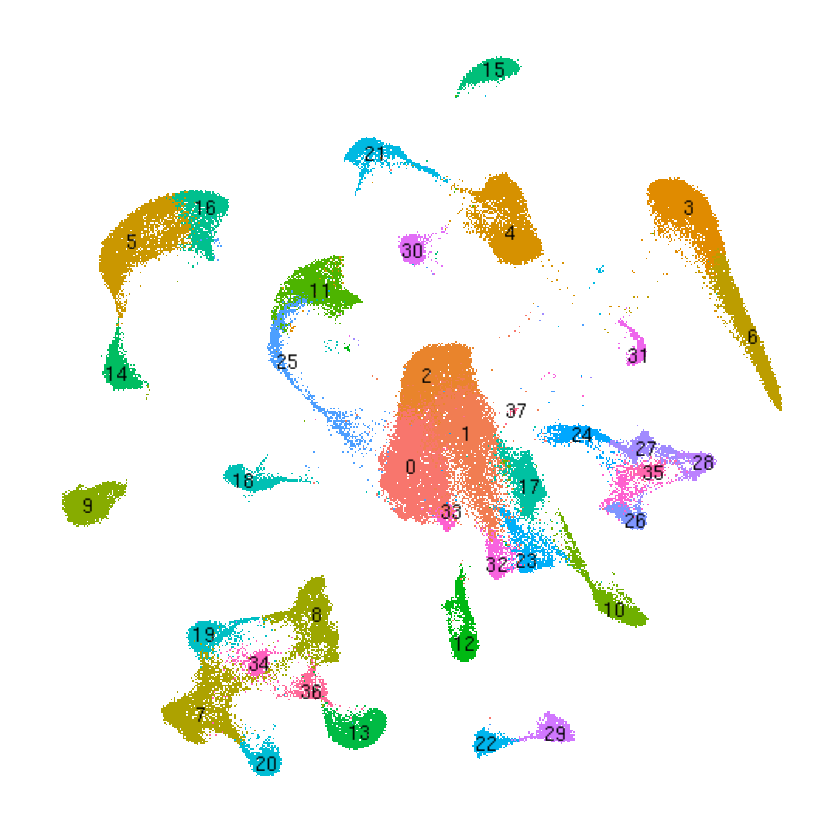

In [29]:
all_integrated_nodub_dimplot <- DimPlot(all_integrated_nodub, reduction = "umap", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
all_integrated_nodub_dimplot

### Remove low intronic read clusters

#### Use "3nextseqs_11_18/3nextseq_run_11_8_endpoint_female" as a representative sample (end-stage)

In [30]:
get_prop_intronic <- function(with_introns, without_introns, barcodes){

    with_introns_all <- subset(with_introns, cells = barcodes$barcode)
    with_introns_all$barcode <- rownames(with_introns_all@meta.data)
    
    without_introns_all <- subset(without_introns, cells = barcodes$barcode)
    without_introns_all$barcode <- rownames(without_introns_all@meta.data)
    
    prop.intronic <- inner_join(with_introns_all@meta.data, without_introns_all@meta.data, by = "barcode")
    prop.intronic$prop_intronic <- (prop.intronic$nCount_RNA.x - prop.intronic$nCount_RNA.y)/prop.intronic$nCount_RNA.x
    prop.intronic <- inner_join(prop.intronic, barcodes, by = "barcode")
    rownames(prop.intronic) <- prop.intronic$orig.barcode
    prop.intronic <- dplyr::select(prop.intronic, prop_intronic)

return(prop.intronic)
}

In [31]:
three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_w_introns <- Read10X('/oak/stanford/groups/agitler/Shared/SOD1_Paper/cellranger_output_w_and_wo_introns/3nextseqs_11_18-3nextseq_run_11_8_endpoint_female_w_introns/outs/raw_feature_bc_matrix') %>% CreateSeuratObject()
three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_wo_introns <- Read10X('/oak/stanford/groups/agitler/Shared/SOD1_Paper/cellranger_output_w_and_wo_introns/3nextseqs_11_18-3nextseq_run_11_8_endpoint_female_wo_introns/outs/raw_feature_bc_matrix') %>% CreateSeuratObject()

In [32]:
all_integrated_nodub_barcodes <- all_integrated_nodub
all_integrated_nodub_barcodes$barcode <- rownames(all_integrated_nodub_barcodes@meta.data)
all_integrated_nodub_barcodes@meta.data <- all_integrated_nodub_barcodes@meta.data %>% mutate(barcode = stringr::str_remove(barcode, "_.+"))

In [33]:
three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_barcodes <- all_integrated_nodub_barcodes@meta.data %>% dplyr::filter(orig.ident == "3nextseqs_11_18/3nextseq_run_11_8_endpoint_female") %>% dplyr::select(barcode)
three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_barcodes$orig.barcode <- rownames(three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_barcodes)

In [34]:
three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_prop_intronic <- get_prop_intronic(three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_w_introns, three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_wo_introns, three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_barcodes)

In [35]:
three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female <- AddMetaData(all_integrated_nodub, three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female_prop_intronic)
three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female <- subset(three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female, orig.ident == "3nextseqs_11_18/3nextseq_run_11_8_endpoint_female")

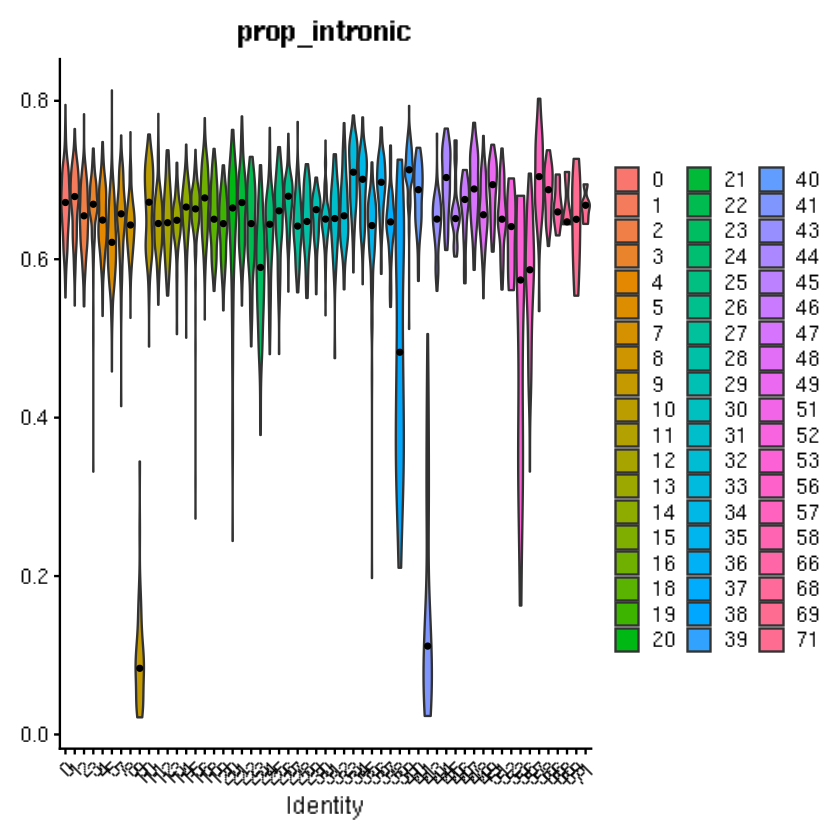

In [36]:
# Use original clustering
prop_intronic_vln <- VlnPlot(
  object = three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female, 
  features = "prop_intronic", 
  group.by = "integrated_snn_res.2",
  pt.size = 0    
) +
  stat_summary(
    fun = median,      
    geom = "point",    
    fill = "black",      
    size = 1          
  )

prop_intronic_vln

In [37]:
metadata_df <- three_nextseqs_11_18_3nextseq_run_11_8_endpoint_female@meta.data %>%
  as.data.frame() %>%
  dplyr::select(prop_intronic, cluster = `integrated_snn_res.2`)

low_intronic_clusters <- metadata_df %>%
  group_by(cluster) %>%
  summarize(median_intronic = median(prop_intronic, na.rm = TRUE)) %>%
  filter(median_intronic < 0.4) %>%
  pull(cluster)

low_intronic_clusters

[1] 9  41
72 Levels: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 71

In [38]:
# Remove low intronic read clusters
Idents(all_integrated_nodub) <- "integrated_snn_res.2"
all_integrated_nodub <- subset(all_integrated_nodub, idents = low_intronic_clusters, invert = TRUE)

#### Re-assess clustering

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



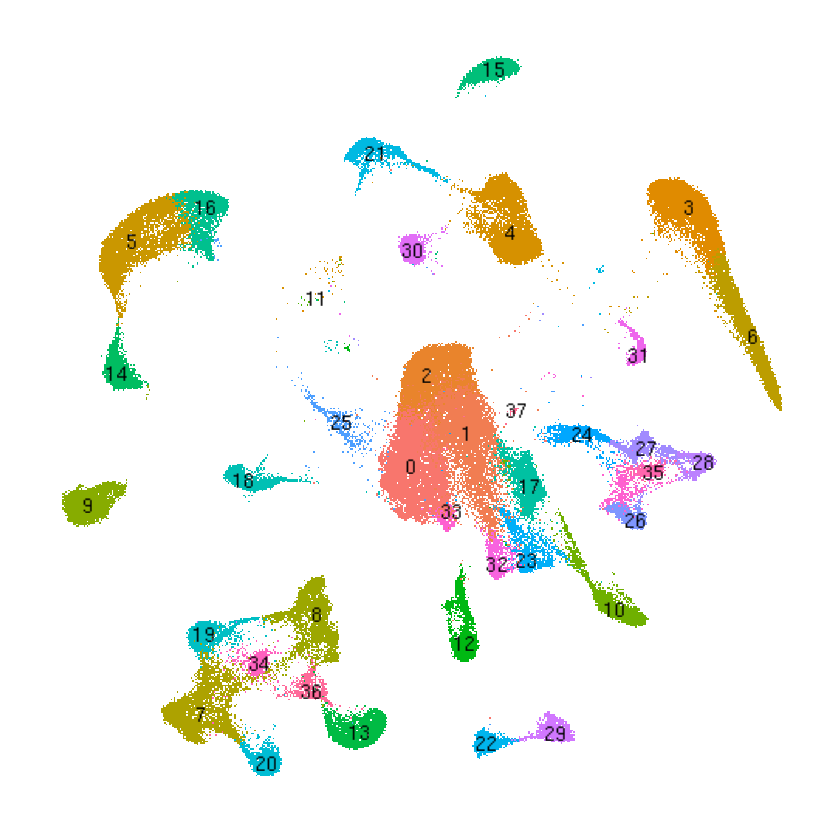

In [39]:
Idents(all_integrated_nodub) <- "seurat_clusters"
all_integrated_nodub_dimplot <- DimPlot(all_integrated_nodub, reduction = "umap", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
all_integrated_nodub_dimplot

In [40]:
# Remove remaining cluster 11 cells (low intronic read)
all_integrated_nodub <- subset(all_integrated_nodub, idents = c('11'), invert = TRUE)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



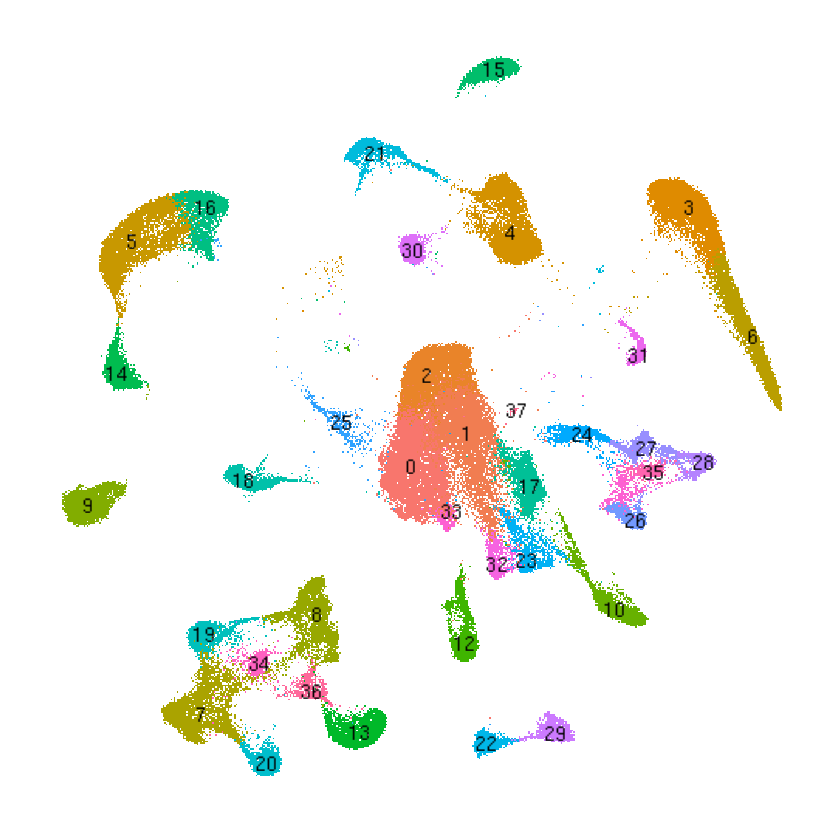

In [41]:
all_integrated_nodub_dimplot <- DimPlot(all_integrated_nodub, reduction = "umap", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
all_integrated_nodub_dimplot

In [42]:
ggsave(all_integrated_nodub_dimplot, filename = paste0(save_dir, "Figures/all_integrated_nodub_final_dimplot.svg"), device='svg', width = 3.55, height = 3.55, units = "in")

In [43]:
saveRDS(all_integrated_nodub, file = paste0(save_dir, 'rds_files/all_integrated_nodub_final.rds'))

## Marker gene heatmap

In [4]:
all_integrated_nodub <- readRDS(file = paste0(save_dir, 'rds_files/all_integrated_nodub_final.rds'))

In [5]:
excitatory_markers <- c('Slc17a6')
inhibitory_markers <- c('Slc32a1')
astro_markers <- c('Aqp4', 'Slc1a2')
microglia_markers <- c('Csf1r')
endo_fibro_markers <- c('Cldn5', 'Dcn', 'Pdgfrb')
oligo_markers <- c('Mog', 'Sox10')
cholin_markers <- c('Slc5a7')
ependymal_markers <- c('Cfap43')
opc_markers <- c('Pdgfra')
disease_markers <- c('Atf3')

all.markers <- c(excitatory_markers, inhibitory_markers, cholin_markers, oligo_markers, 
                 astro_markers, microglia_markers, endo_fibro_markers, ependymal_markers, opc_markers, 
                 disease_markers)

In [6]:
DefaultAssay(all_integrated_nodub) <- "RNA"

Idents(all_integrated_nodub) <- all_integrated_nodub$seurat_clusters
heatmap.avgexp <- AverageExpression(all_integrated_nodub, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))

Warning message:
“The following 1 features were not found in the integrated assay: Slc32a1”


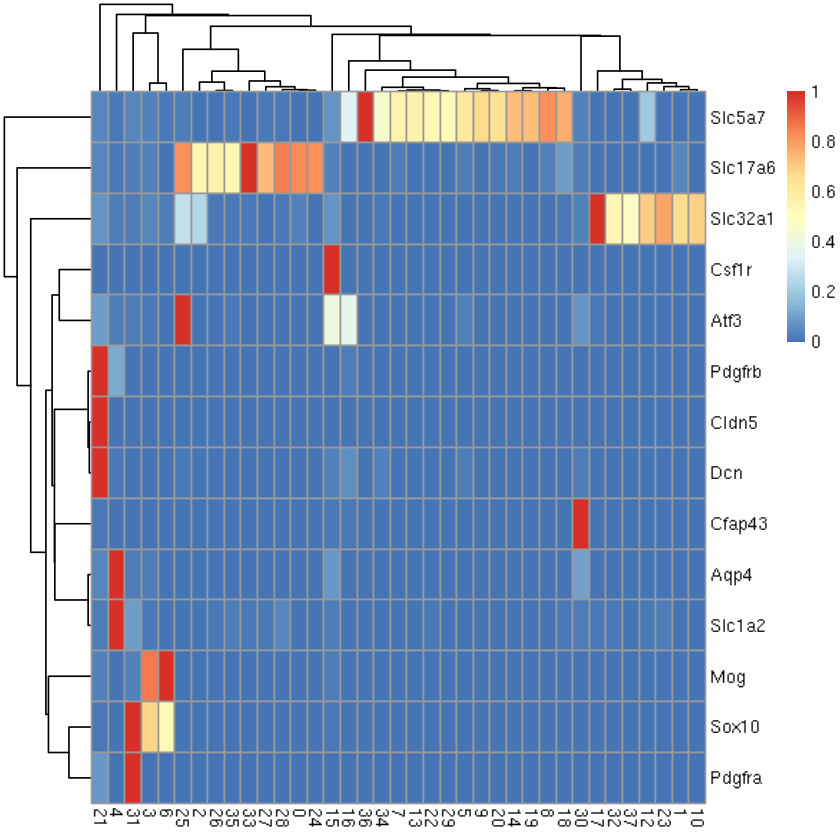

In [7]:
pheatmap(heatmap.avgexp)

In [8]:
row_order <- c('18','8','19','14','20','9','5','36','29','22','13','7','34','16','12','17','32','37','23','1','10','2','26','35','33','27','28','0','24','25','4','6','3','31','15','30','21')
heatmap.avgexp <- heatmap.avgexp[,row_order]

col_order <- c('Slc5a7','Slc32a1','Slc17a6','Atf3','Aqp4','Slc1a2','Mog','Sox10','Pdgfra','Csf1r','Cfap43','Cldn5','Dcn','Pdgfrb')
heatmap.avgexp <- heatmap.avgexp[col_order,]

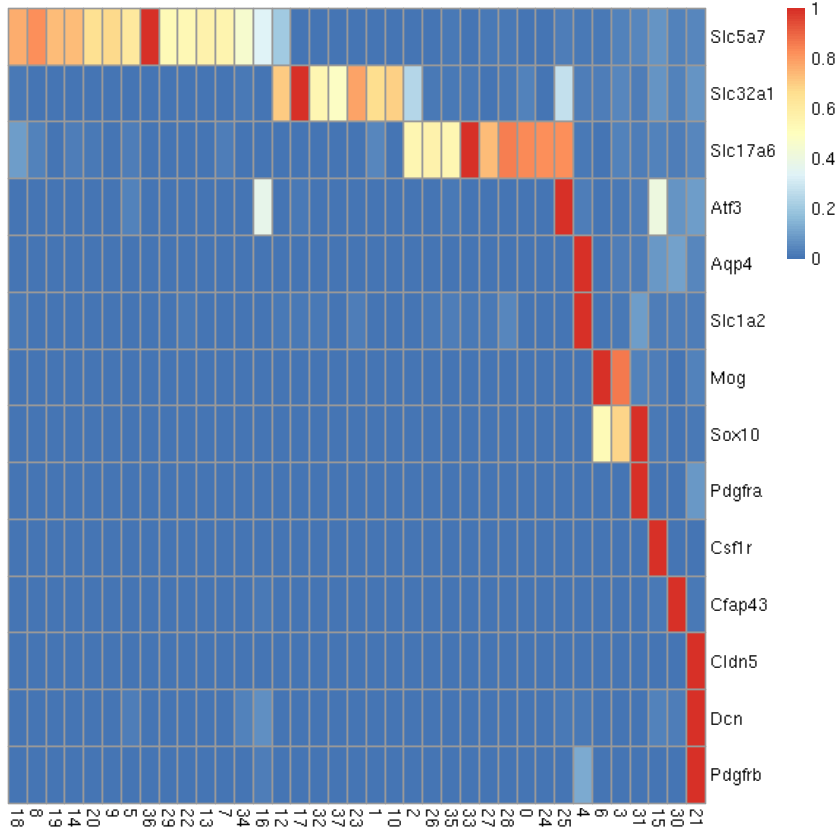

In [9]:
pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

In [12]:
pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE, filename = paste0(save_dir, 'Figures/all_integrated_nodub_final_heatmap.pdf'), width = 4.2827, height = 2.15, fontsize = 7)

## Add cell class information to metadata

In [50]:
all_integrated_annotated <- all_integrated_nodub

In [51]:
nonChol_interneuron_indices <- all_integrated_annotated$seurat_clusters %in% c(17, 32, 37, 23, 1, 10, 2, 26, 35, 33, 27, 28, 0, 24)
dai_index <- all_integrated_annotated$seurat_clusters %in% c(25)
astrocyte_index <- all_integrated_annotated$seurat_clusters %in% c(4)
oligodendrocyte_indices <- all_integrated_annotated$seurat_clusters %in% c(6, 3)
opc_index <- all_integrated_annotated$seurat_clusters %in% c(31)
microglia_index <- all_integrated_annotated$seurat_clusters %in% c(15)
ependymal_index <- all_integrated_annotated$seurat_clusters %in% c(30)
vasc_perivasc_index <- all_integrated_annotated$seurat_clusters %in% c(21)

In [52]:
all_integrated_annotated$cell_class <- "Cholinergic Neurons"
all_integrated_annotated$cell_class[nonChol_interneuron_indices] <- "Non-Cholinergic Interneurons" 
all_integrated_annotated$cell_class[dai_index] <- "Disease-Associated Interneurons"
all_integrated_annotated$cell_class[astrocyte_index] <- "Astrocytes"
all_integrated_annotated$cell_class[oligodendrocyte_indices] <- "Oligodendrocytes"
all_integrated_annotated$cell_class[opc_index] <- "OPCs"
all_integrated_annotated$cell_class[microglia_index] <- "Microglia/Macrophages"
all_integrated_annotated$cell_class[ependymal_index] <- "Ependymal Cells"
all_integrated_annotated$cell_class[vasc_perivasc_index] <- "Vascular & Perivascular Cells"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



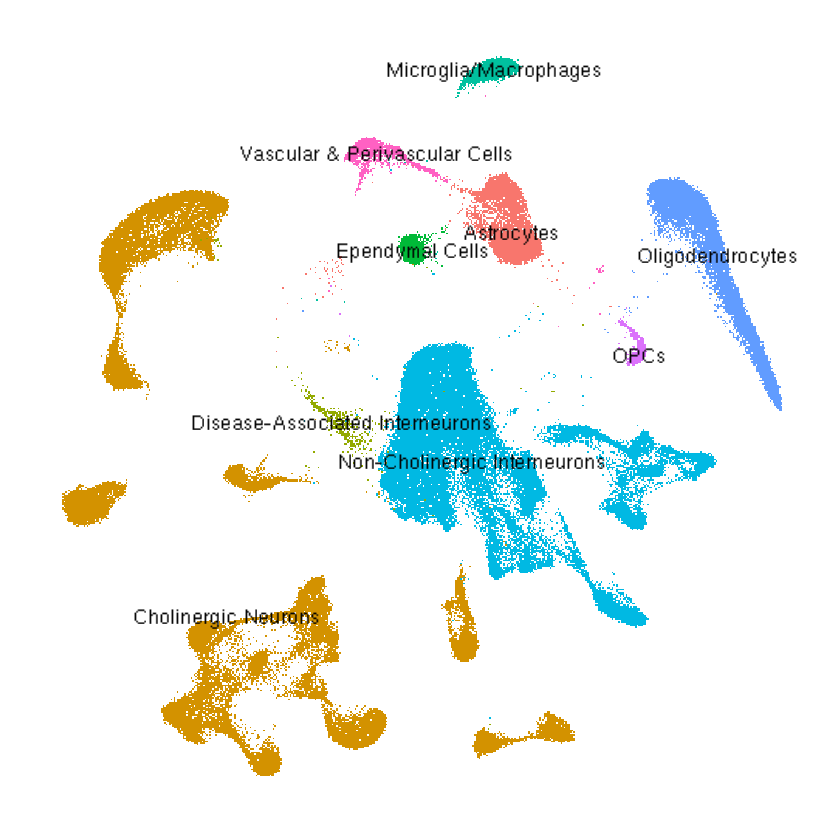

In [53]:
all_integrated_annotated_dimplot <- DimPlot(all_integrated_annotated, reduction = "umap", group.by = "cell_class", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
all_integrated_annotated_dimplot

In [54]:
ggsave(all_integrated_annotated_dimplot, filename = paste0(save_dir, "Figures/all_integrated_annotated_final_dimplot.svg"), device='svg', width = 3.55, height = 3.55, units = "in")

In [55]:
saveRDS(all_integrated_annotated, file = paste0(save_dir, 'rds_files/all_integrated_annotated_final.rds'))

### Get the percentage of cholinergic neuron nuclei

In [56]:
total_nuclei <- ncol(all_integrated_annotated)  # Total number of nuclei (cells)
cholinergic_nuclei <- sum(all_integrated_annotated$cell_class == "Cholinergic Neurons")  # Count of cholinergic neurons

# Calculate percentage
percentage_cholinergic <- (cholinergic_nuclei / total_nuclei) * 100
percentage_cholinergic

[1] 39.11548

## Subset cholingergic neurons and subcluster

In [4]:
all_integrated_annotated <- readRDS(file = paste0(save_dir, 'rds_files/all_integrated_annotated_final.rds'))

In [5]:
cholinergic_subset <- subset(all_integrated_annotated, subset = cell_class == "Cholinergic Neurons")

In [6]:
# Find variable features using the RNA assay
DefaultAssay(cholinergic_subset) <- "RNA"
cholinergic_subset <- FindVariableFeatures(cholinergic_subset, verbose = FALSE)

# Perform remaining steps using the integrated assay
DefaultAssay(cholinergic_subset) <- "integrated"
cholinergic_subset <- ScaleData(cholinergic_subset, verbose = FALSE)
cholinergic_subset <- RunPCA(cholinergic_subset, verbose = FALSE)
cholinergic_subset <- RunUMAP(cholinergic_subset, reduction = "pca", dims = 1:13, verbose = FALSE)
cholinergic_subset <- FindNeighbors(cholinergic_subset, reduction = "pca", dims = 1:13, verbose = FALSE)
cholinergic_subset <- FindClusters(cholinergic_subset, resolution = 0.4, verbose = FALSE)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


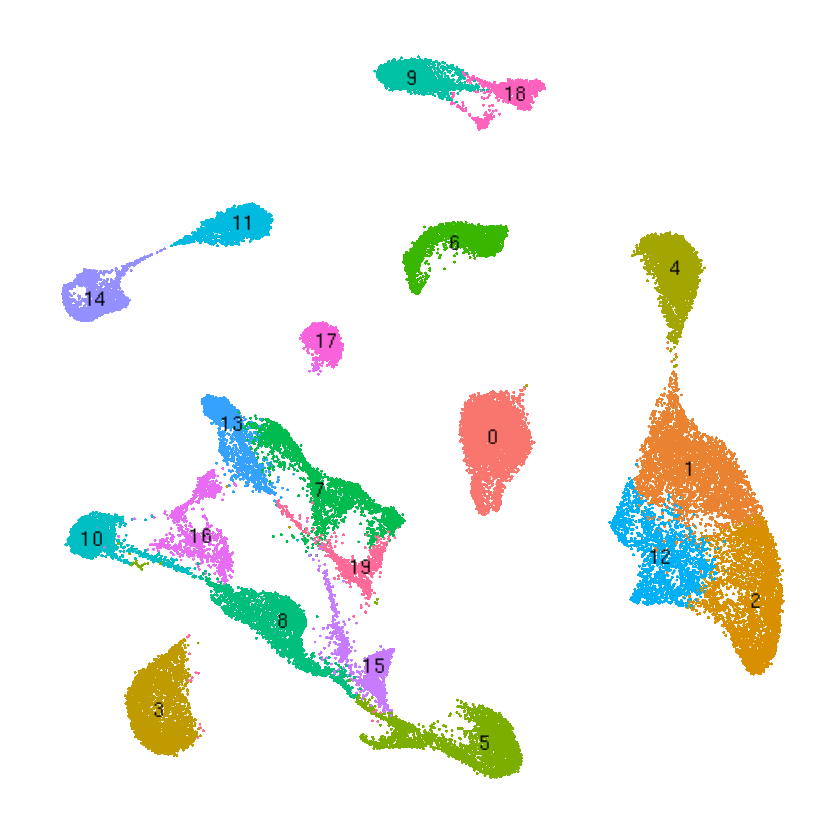

In [7]:
# Visualization 
cholinergic_dimplot <- DimPlot(cholinergic_subset, reduction = "umap", label = TRUE) + NoLegend() + NoAxes() + NoLegend() + theme(plot.title = element_blank())
cholinergic_dimplot <- rasterize(cholinergic_dimplot, layers='Point', dpi=1000)
cholinergic_dimplot

In [8]:
ggsave(cholinergic_dimplot, filename = paste0(save_dir, "Figures/cholinergic_dimplot.svg"), device='svg', width = 3.55, height = 3.55, units = "in")

In [9]:
saveRDS(cholinergic_subset, file = paste0(save_dir, 'rds_files/cholinergic_subset.rds'))

## Marker gene heatmap

In [13]:
cholinergic_subset <- readRDS(file = paste0(save_dir, 'rds_files/cholinergic_subset.rds'))

In [14]:
all.markers <- c(
    "Bcl6", #Skeletal
    "Fbn2", "Zeb2", #Visceral
    "Rxfp1", #Sacral visceral
    "Pitx2", #Pitx2+
    "Gad1", #Inhibitory
    "Mrvi1", "Stk32a", #Alpha
    "Npas1", #Pan-gamma
    "Plch1", #Gamma*
    "Pard3b" #Gamma
  )

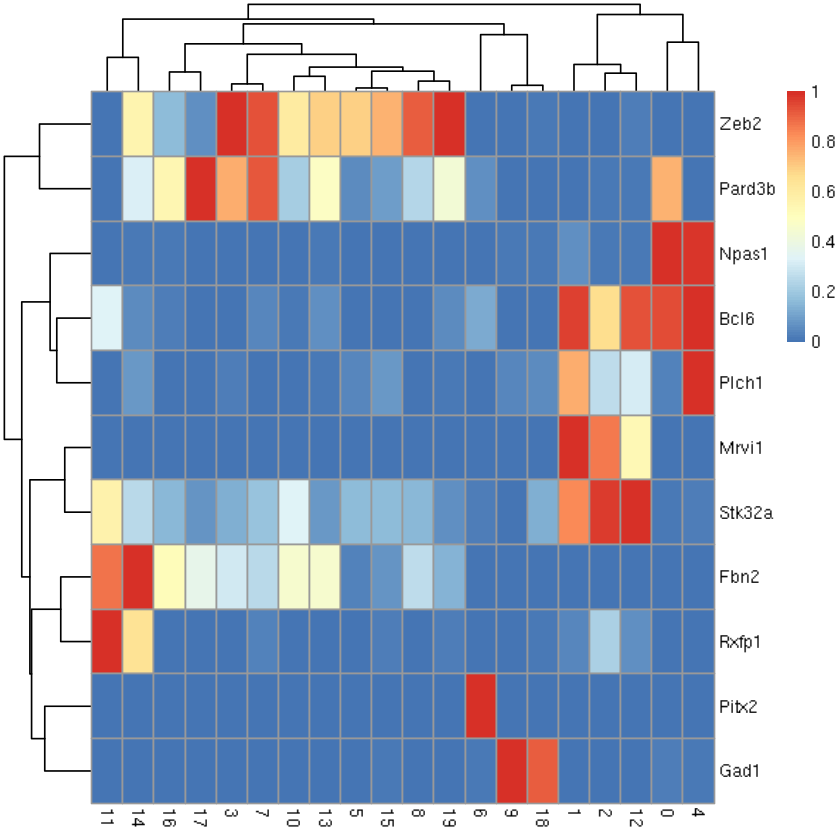

In [15]:
DefaultAssay(cholinergic_subset) <- "RNA"

Idents(cholinergic_subset) <- cholinergic_subset$seurat_clusters
heatmap.avgexp <- AverageExpression(cholinergic_subset, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))
pheatmap(heatmap.avgexp)

In [16]:
col_order <- c('2','1','12','4','0','6','18','9','5','15','19','3','7','8','13','10','16','17','14','11')
heatmap.avgexp <- heatmap.avgexp[,col_order]

row_order <- c('Bcl6','Stk32a','Mrvi1','Npas1','Plch1','Pard3b','Pitx2','Gad1','Zeb2','Fbn2','Rxfp1')
heatmap.avgexp <- heatmap.avgexp[row_order,]

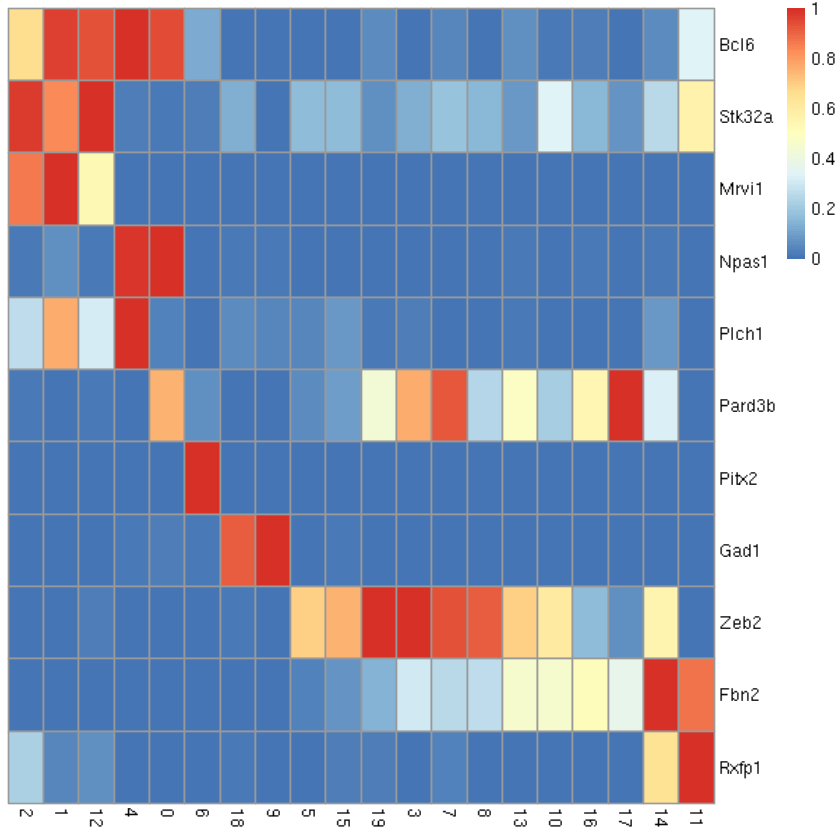

In [17]:
pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

In [18]:
pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE, filename = paste0(save_dir, 'Figures/cholinergic_type_heatmap_final.pdf'), width = 4.2827, height = 2.15, fontsize = 7)

## Add cholinergic type information to metadata

In [21]:
cholinergic_annotated <- cholinergic_subset

In [22]:
alpha_indices <- cholinergic_annotated$seurat_clusters %in% c(1, 2, 12)
gamma_index <- cholinergic_annotated$seurat_clusters %in% c(0)
gammaStar_index <- cholinergic_annotated$seurat_clusters %in% c(4)
visceralSacral_indices <- cholinergic_annotated$seurat_clusters %in% c(11, 14)
pitx2_index <- cholinergic_annotated$seurat_clusters %in% c(6)
inhibitory_indices <- cholinergic_annotated$seurat_clusters %in% c(9, 18)

In [23]:
cholinergic_annotated$cholinergic_type <- "Visceral Thoracic MNs"
cholinergic_annotated$cholinergic_type[alpha_indices] <- "Alpha MNs"
cholinergic_annotated$cholinergic_type[gamma_index] <- "Gamma MNs" 
cholinergic_annotated$cholinergic_type[gammaStar_index] <- "Gamma Star MNs"
cholinergic_annotated$cholinergic_type[visceralSacral_indices] <- "Visceral Sacral MNs"
cholinergic_annotated$cholinergic_type[pitx2_index] <- "Pitx2+ Cholinergic Interneurons"
cholinergic_annotated$cholinergic_type[inhibitory_indices] <- "Gad1+ Cholinergic Interneurons"

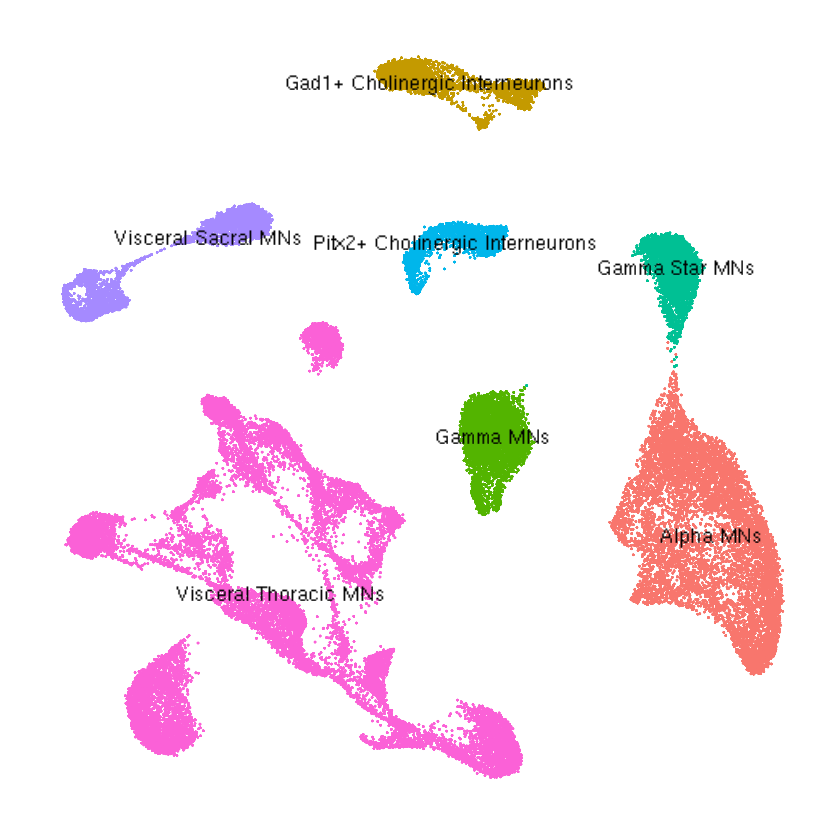

In [24]:
cholinergic_annotated_dimplot <- DimPlot(cholinergic_annotated, reduction = "umap", group.by = "cholinergic_type", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
cholinergic_annotated_dimplot <- rasterize(cholinergic_annotated_dimplot, layers='Point', dpi=500)
cholinergic_annotated_dimplot

In [25]:
ggsave(cholinergic_annotated_dimplot, filename = paste0(save_dir, "Figures/cholinergic_annotated_dimplot.svg"), device='svg', width = 3.55, height = 3.55, units = "in")

In [26]:
saveRDS(cholinergic_annotated, file = paste0(save_dir, 'rds_files/cholinergic_annotated.rds'))

## Subset alpha motor neurons and subcluster

In [27]:
cholinergic_annotated <- readRDS(file = paste0(save_dir, 'rds_files/cholinergic_annotated.rds'))

In [28]:
alpha_subset <- subset(cholinergic_annotated, subset = cholinergic_type == "Alpha MNs")

In [29]:
# Find variable features using the RNA assay
DefaultAssay(alpha_subset) <- "RNA"
alpha_subset <- FindVariableFeatures(alpha_subset, verbose = FALSE)

# Perform remaining steps using the integrated assay
DefaultAssay(alpha_subset) <- "integrated"
alpha_subset <- ScaleData(alpha_subset, verbose = FALSE)
alpha_subset <- RunPCA(alpha_subset, verbose = FALSE)
alpha_subset <- RunUMAP(alpha_subset, reduction = "pca", dims = 1:12, verbose = FALSE)
alpha_subset <- FindNeighbors(alpha_subset, reduction = "pca", dims = 1:12, verbose = FALSE)
alpha_subset <- FindClusters(alpha_subset, resolution = 0.7, verbose = FALSE)

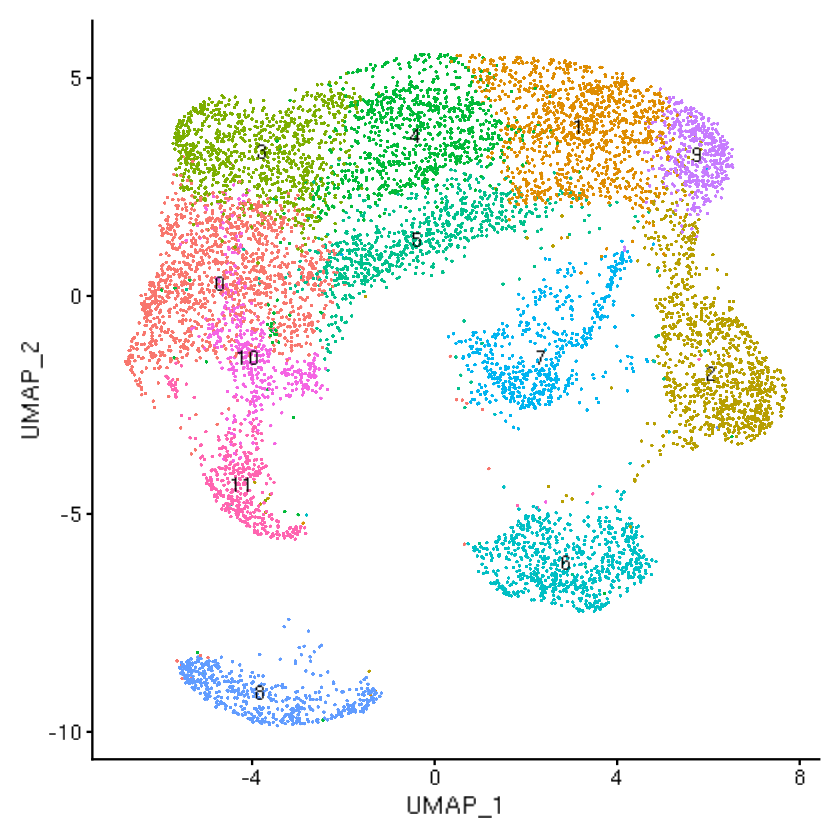

In [30]:
# Visualization
alpha_UMAP <- DimPlot(alpha_subset, reduction = "umap", label = TRUE) + NoLegend() 
alpha_UMAP <- rasterize(alpha_UMAP, layers='Point', dpi=1000)
alpha_UMAP

In [31]:
saveRDS(alpha_subset, file = paste0(save_dir, 'rds_files/alpha_subset.rds'))